## Hay una base de ingredientes que se necesitan filtrar, analizar y reportar su estatus de aprobacion.

In [16]:
# Como primer paso: Importar Pandas
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
print("Entorno listo. Version pandas:", pd.__version__)

Entorno listo. Version pandas: 2.2.2


El producto analizado es **Coca Cola Zero**, cuya formula real contiene:

* Aspartame y Acesulfame k (Edulcorantes de alta intensidad)
* Colorante Caramelo Clase IV (En etiquetado como Colorante 150d)
* Acido Fosforico como acidulante principal
* Benzoato de Sodio (Conservador)
* Cafeina como ingrediente funcional

In [18]:
# Paso 2: se crea el dataset de ingredientes del producto "Coca Cola Zero Azúcar"

data = {
    'ingrediente': [
        'Caramelo Clase IV',
        'Acido Fosforico',
        'Aspartame',
        'Acesulfame K',
        'Acido Citrico',
        'Benzoato de Sodio',
        'Cafeina',
        'Saborizante Natural'
        # Fuente: Etiqueta oficial del producto
    ], 
     #Por cada ingrediente, se asigna un provedor distinto
    'proveedor': [
        'Proveedor A',
        'Proveedor B',
        'Proveedor C',
        'Proveedor C',
        'Proveedor B',
        'Proveedor D',
        'Proveedor A',
        'Proveedor E'
    ],
    # Se asigna una categoría de cada ingrediente (esta de acuerdo a la NOM)
    'categoria': [
        'Colorante',
        'Acidulante',
        'Edulcorante',
        'Edulcorante',
        'Acidulante',
        'Conservador',
        'Estimulante',
        'Saborizante'
    ],
    # Estado de cada saborizante
    'estatus': [
        'Aprobado',
        'Aprobado',
        'En revision',
        'Aprobado',
        'Aprobado',
        'Pendiente',
        'Aprobado',
        'Pendiente'
    ],
    #Normas que se aplican en cada ingrediente
    'norma_aplicable': [
        'NOM-251 / Codex Stan 192',
        'FDA 21 CFR 582.1 / NOM-251',
        'Codex Stan 192 / NOM-218',
        'Codex Stan 192 / NOM-218',
        'NOM-251 / Codex Stan 192',
        'NOM-251 / FDA 21 CFR',
        'FDA 21 CFR 182.1180',
        'NOM-051 / GRAS'
    ],
     # Se divide el tiempo (dias) en lo que se tarda el proceso de aprobar un ingrediente
    'dias_en_proceso': [0, 0, 22, 0, 0, 38, 0, 15]
} 

df = pd.DataFrame(data)
print(df)

           ingrediente    proveedor    categoria      estatus  \
0    Caramelo Clase IV  Proveedor A    Colorante     Aprobado   
1      Acido Fosforico  Proveedor B   Acidulante     Aprobado   
2            Aspartame  Proveedor C  Edulcorante  En revision   
3         Acesulfame K  Proveedor C  Edulcorante     Aprobado   
4        Acido Citrico  Proveedor B   Acidulante     Aprobado   
5    Benzoato de Sodio  Proveedor D  Conservador    Pendiente   
6              Cafeina  Proveedor A  Estimulante     Aprobado   
7  Saborizante Natural  Proveedor E  Saborizante    Pendiente   

              norma_aplicable  dias_en_proceso  
0    NOM-251 / Codex Stan 192                0  
1  FDA 21 CFR 582.1 / NOM-251                0  
2    Codex Stan 192 / NOM-218               22  
3    Codex Stan 192 / NOM-218                0  
4    NOM-251 / Codex Stan 192                0  
5        NOM-251 / FDA 21 CFR               38  
6         FDA 21 CFR 182.1180                0  
7              NOM-051

#### Paso 2: Analisis del estatus de aprobacion

Filtramos los ingredientes que **no estan aprobados**

- **df['estatus'] != 'Aprobado'** crea una mascara booleana (True/False por cada fila)
- **df[...]** aplica esa mascara para quedarnos solo con las filas que cumplen la condicion
- **.mean()** calcula el promedio de dias en proceso de esos ingredientes

########### Este tipo de filtrado es el nucleo del monitoreo de ciclo de vida de formulas.

In [20]:
# Conteo de ingredientes por estatus
print("--- Distribucion de estatus ---")
print(df['estatus'].value_counts())

# Filtrar ingredientes que requieren acción (no aprobados)
requieren_accion = df[df['estatus'] != 'Aprobado']

print("\n--- Ingredientes que requieren accion ---")
print(requieren_accion[['ingrediente', 'categoria', 'estatus', 'norma_aplicable', 'dias_en_proceso']])

# Tiempo promedio en proceso
promedio_dias = requieren_accion['dias_en_proceso'].mean()
print(f"\nPromedio de dias en proceso: {promedio_dias:.1f} dias")

--- Distribucion de estatus ---
estatus
Aprobado       5
Pendiente      2
En revision    1
Name: count, dtype: int64

--- Ingredientes que requieren accion ---
           ingrediente    categoria      estatus           norma_aplicable  \
2            Aspartame  Edulcorante  En revision  Codex Stan 192 / NOM-218   
5    Benzoato de Sodio  Conservador    Pendiente      NOM-251 / FDA 21 CFR   
7  Saborizante Natural  Saborizante    Pendiente            NOM-051 / GRAS   

   dias_en_proceso  
2               22  
5               38  
7               15  

Promedio de dias en proceso: 25.0 dias


In [21]:
# Estadisticas con numpy
dias = np.array(df['dias_en_proceso'])
print(f"\nPromedio de dias en proceso (todos): {np.mean(dias):.1f}")
print(f"Maximo dias en proceso: {np.max(dias)}")
print(f"Desviacion estandar: {np.std(dias):.1f}")

dias_pendientes = np.array(requieren_accion['dias_en_proceso'])
print(f"Promedio dias en proceso (solo pendientes/revision): {np.mean(dias_pendientes):.1f}")



Promedio de dias en proceso (todos): 9.4
Maximo dias en proceso: 38
Desviacion estandar: 13.5
Promedio dias en proceso (solo pendientes/revision): 25.0


#### Paso 4: Visualización

Generamos dos gráficas:

1. **Grafica de dona** — distribucion del estatus de todos los ingredientes. Da una vista rapida del estado general de la formula.
2. **Grafica de barras horizontales** — dias en proceso de cada ingrediente pendiente. Permite priorizar cuales llevan mas tiempo sin resolucion.

Estas visualizaciones son analogas a las que se construirian en un dashboard de Power BI para monitoreo de aprobaciones.

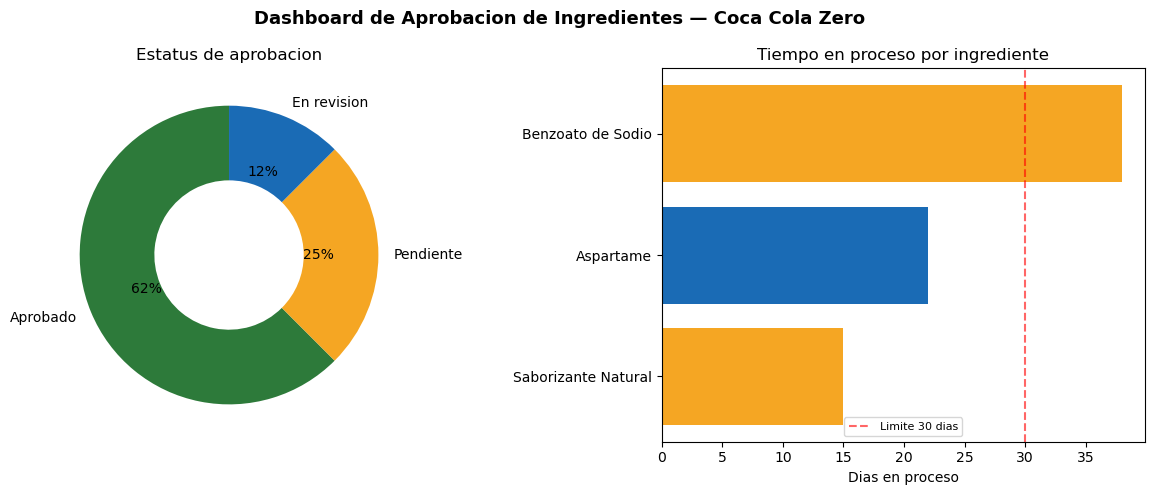

In [23]:
# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Dashboard de Aprobacion de Ingredientes — Coca Cola Zero',
             fontsize=13, fontweight='bold')

conteo = df['estatus'].value_counts()
colores = {'Aprobado': '#2d7a3a', 'En revision': '#1a6bb5', 'Pendiente': '#f5a623'}
colores_lista = [colores[s] for s in conteo.index]

axes[0].pie(
    conteo,
    labels=conteo.index,
    autopct='%1.0f%%',
    colors=colores_lista,
    wedgeprops=dict(width=0.5),
    startangle=90
)
axes[0].set_title('Estatus de aprobacion')

pendientes = df[df['dias_en_proceso'] > 0].sort_values('dias_en_proceso', ascending=True)
colores_barras = [colores.get(e, '#888') for e in pendientes['estatus']]
axes[1].barh(pendientes['ingrediente'], pendientes['dias_en_proceso'], color=colores_barras)
axes[1].set_xlabel('Dias en proceso')
axes[1].set_title('Tiempo en proceso por ingrediente')
axes[1].axvline(x=30, color='red', linestyle='--', alpha=0.6, label='Limite 30 dias')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('dashboard_cocazero.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
requieren_accion.to_csv('reporte_pendientes_cocazero.csv', index=False)
print("\nReporte exportado: reporte_pendientes_cocazero.csv")


Reporte exportado: reporte_pendientes_cocazero.csv
